# Carga y Preparación Inicial #

In [65]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

RUTA_NOTEBOOK = Path.cwd()
BASE_DIR = RUTA_NOTEBOOK.parent

DIR_RAW = BASE_DIR / "data" / "raw"
DIR_PROCESSED = BASE_DIR / "data" / "processed"

PATH_ENTRADA = BASE_DIR / "data" / "processed" / "datos_clean_cafeteria.csv"
PATH_SALIDA = BASE_DIR / "data" / "processed" / "datos_analyzed_cafeteria.csv"
PATH_GRAPHIC = BASE_DIR / "assets"

DIR_PROCESSED.mkdir(parents=True, exist_ok=True)

print(f"Raiz del proyecto: {BASE_DIR}")
print(f"Buscando en: {PATH_ENTRADA}")
print(f"Guadando salida en: {PATH_SALIDA}") 

Raiz del proyecto: c:\Users\OAD\Documents\dashboard-and-analysis-coffeeshop
Buscando en: c:\Users\OAD\Documents\dashboard-and-analysis-coffeeshop\data\processed\datos_clean_cafeteria.csv
Guadando salida en: c:\Users\OAD\Documents\dashboard-and-analysis-coffeeshop\data\processed\datos_analyzed_cafeteria.csv


In [66]:
df = pd.read_csv(PATH_ENTRADA)

In [67]:
print(df.shape)
df

(13182, 12)


,ID_Ticket,RUT_Cliente,Fecha_Hora,Producto_Categoria,Producto_Detail,Cantidad,Precio_Unitario_IVA,Precio_Unitario_Neto,Coste_Producto,Metodo_Pago,Numero de mesa,Tipo de servicio
0,TX-20000,987654321,2025-01-01 09:06:00.000000000,Bebestibles,Jugo De Arándano,3,3100,2605,950,Débito,3,Para servir
1,TX-20000,987654321,2025-01-01 09:12:07.000000000,Repostería,Muffin De Vainilla Natural,2,2100,1765,550,Débito,3,Para servir
2,TX-20001,CONSUMIDOR FINAL,2025-01-01 09:20:48.000000000,Cafés,Espresso Doble,2,2490,2092,600,Crédito,6,Para servir
3,TX-20001,CONSUMIDOR FINAL,2025-01-01 09:22:47.000000000,Bebestibles,Jugo Naranja Natural,1,2990,2513,900,Crédito,6,Para servir
4,TX-20001,CONSUMIDOR FINAL,2025-01-01 09:27:58.000000000,Sandwicheria,Croissant Caprese,1,4790,4025,1500,Crédito,6,Para servir
...,...,...,...,...,...,...,...,...,...,...,...,...
13177,TX-24497,CONSUMIDOR FINAL,2025-12-31 19:35:19.680000095,Bebestibles,Jugo De Piña,1,2990,2513,900,Débito,7,Para servir
13178,TX-24498,CONSUMIDOR FINAL,2025-12-31 19:36:00.000000000,Repostería,Medialuna Dulce,1,1400,1176,350,Débito,2,Para servir
13179,TX-24498,CONSUMIDOR FINAL,2025-12-31 19:39:13.000000000,Cafés,Flat White,1,3000,2521,800,Débito,2,Para servir
13180,TX-24499,CONSUMIDOR FINAL,2025-12-31 19:40:25.000000000,Cafés,Americano,3,2200,1849,500,Débito,6,Para servir


In [68]:
df.dtypes

ID_Ticket               object
RUT_Cliente             object
Fecha_Hora              object
Producto_Categoria      object
Producto_Detail         object
Cantidad                 int64
Precio_Unitario_IVA      int64
Precio_Unitario_Neto     int64
Coste_Producto           int64
Metodo_Pago             object
Numero de mesa           int64
Tipo de servicio        object
dtype: object

In [69]:
df["Fecha_Hora"] = pd.to_datetime(df["Fecha_Hora"])

In [70]:
df.dtypes

ID_Ticket                       object
RUT_Cliente                     object
Fecha_Hora              datetime64[ns]
Producto_Categoria              object
Producto_Detail                 object
Cantidad                         int64
Precio_Unitario_IVA              int64
Precio_Unitario_Neto             int64
Coste_Producto                   int64
Metodo_Pago                     object
Numero de mesa                   int64
Tipo de servicio                object
dtype: object

---

# Análisis #

**¿Cuánto margen entrega cada producto?**

In [71]:
df["Margen_Unitario"] = df["Precio_Unitario_Neto"] - df["Coste_Producto"]

df['Ingreso_Total'] = df['Precio_Unitario_Neto'] * df['Cantidad']
df['Margen_Total'] = df['Margen_Unitario'] * df['Cantidad']

resumen_categoria = df.groupby('Producto_Categoria').apply(
    lambda x: pd.Series({
        'Ingreso_Total': x['Ingreso_Total'].sum(),
        'Margen_Total_Abs': x['Margen_Total'].sum(),
        'Margen_Ponderado_Pct': (x['Margen_Total'].sum() / x['Ingreso_Total'].sum()) * 100
    })
).reset_index()

print(resumen_categoria)

  Producto_Categoria  Ingreso_Total  Margen_Total_Abs  Margen_Ponderado_Pct
0        Bebestibles      7820706.0         5014256.0             64.115132
1              Cafés     18980963.0        13526813.0             71.265157
2         Repostería      8791099.0         5967499.0             67.881149
3       Sandwicheria     20043485.0        12382185.0             61.776607


C:\Users\OAD\AppData\Local\Temp\ipykernel_10900\3023409617.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen_categoria = df.groupby('Producto_Categoria').apply(


In [72]:
df.head(1)

,ID_Ticket,RUT_Cliente,Fecha_Hora,Producto_Categoria,Producto_Detail,Cantidad,Precio_Unitario_IVA,Precio_Unitario_Neto,Coste_Producto,Metodo_Pago,Numero de mesa,Tipo de servicio,Margen_Unitario,Ingreso_Total,Margen_Total
0,TX-20000,987654321,2025-01-01 09:06:00,Bebestibles,Jugo De Arándano,3,3100,2605,950,Débito,3,Para servir,1655,7815,4965


In [73]:
df["Margen_Pct"] = (df["Margen_Unitario"] / df["Precio_Unitario_Neto"]) * 100

dispersion_categoria = df.groupby('Producto_Categoria').agg(
    Margen_Pct_Promedio=('Margen_Pct', 'mean'),
    Margen_Pct_Mediana=('Margen_Pct', 'median'),
    Margen_Pct_Std=('Margen_Pct', 'std'),
    # Coeficiente de Variación (CV): Std / Mean * 100
    CV_Margen=('Margen_Pct', lambda x: (x.std() / x.mean()) * 100 if x.mean() != 0 else 0),
    # Rango Intercuartílico (IQR) para identificar variabilidad en volumen
    IQR_Ventas=('Cantidad', lambda x: x.quantile(0.75) - x.quantile(0.25))
).reset_index()

print(dispersion_categoria)

  Producto_Categoria  Margen_Pct_Promedio  Margen_Pct_Mediana  Margen_Pct_Std  \
0        Bebestibles            64.141412           64.186232        0.438655   
1              Cafés            71.946662           71.319312        3.742606   
2         Repostería            68.227555           67.550027        1.682984   
3       Sandwicheria            61.883505           62.417789        0.962002   

   CV_Margen  IQR_Ventas  
0   0.683888         1.0  
1   5.201918         1.0  
2   2.466722         1.0  
3   1.554537         1.0  


In [74]:
tabla_productos = df[["Producto_Categoria", "Producto_Detail", "Precio_Unitario_Neto", "Coste_Producto"]].drop_duplicates()
tabla_productos = tabla_productos.reset_index(drop=True)

In [75]:
tabla_productos["Margen"] = (df["Precio_Unitario_Neto"] - df["Coste_Producto"])
tabla_productos["Margen %"] = (((df["Precio_Unitario_Neto"] - df["Coste_Producto"]) / df["Precio_Unitario_Neto"]) * 100).round(2)


In [76]:
tabla_productos.sort_values(by="Margen %", ascending=False)

,Producto_Categoria,Producto_Detail,Precio_Unitario_Neto,Coste_Producto,Margen,Margen %
16,Cafés,Té Matcha Latte,3025,950,1365,77.34
5,Cafés,Té Verde,1765,400,1365,77.34
8,Cafés,Té Negro,1765,400,1365,77.34
19,Repostería,Medialuna Dulce,1176,350,1483,76.72
7,Cafés,Té Blanco,1933,450,1483,76.72
20,Cafés,Café Latte,2689,850,1349,72.96
11,Sandwicheria,Sándwich Mechada Queso,4613,1800,1349,72.96
9,Bebestibles,Jugo De Piña,2513,900,1492,71.32
2,Cafés,Espresso Doble,2092,600,1492,71.32
17,Cafés,Flat White,2521,800,1805,69.29


In [77]:
resumen_categoria = tabla_productos.groupby("Producto_Categoria").agg(
    Precio_Promedio = ("Precio_Unitario_Neto", "mean"),
    Coste_Promedio = ("Coste_Producto", "mean"),
    Margen_Promedio = ("Margen", "mean"),
    Margen_Pct_Promedio = ("Margen %", "mean")
)

In [78]:
resumen_categoria

,Precio_Promedio,Coste_Promedio,Margen_Promedio,Margen_Pct_Promedio
Producto_Categoria,,,,
Bebestibles,2475.000000,887.500000,1708.750000,66.910000
Cafés,2310.100000,665.000000,1461.500000,71.670000
Repostería,1764.833333,566.666667,1886.833333,66.055000
Sandwicheria,4098.000000,1566.666667,2098.333333,64.261667


In [79]:
# 1. Agrupar por Categoría y Producto desde el DataFrame transaccional
tabla_completa = df.groupby(['Producto_Categoria', 'Producto_Detail']).agg(
    Cantidad=('Cantidad', 'sum'),
    Precio_Neto=('Precio_Unitario_Neto', 'first'),
    Coste=('Coste_Producto', 'first')
).reset_index()

# 2. Calcular las métricas de ganancia y margen
tabla_completa['Ganancia'] = tabla_completa['Precio_Neto'] - tabla_completa['Coste']
tabla_completa['Margen_%'] = ((tabla_completa['Ganancia'] / tabla_completa['Precio_Neto']) * 100).round(2)

In [80]:
tabla_completa["Ganancia_Total"] = tabla_completa["Cantidad"] * tabla_completa["Ganancia"]
tabla_completa["Coste_Total"] = tabla_completa["Cantidad"] * tabla_completa["Coste"]

tabla_completa["Margen % Total"] = (((tabla_completa["Ganancia_Total"] - tabla_completa["Coste_Total"]) / tabla_completa["Ganancia_Total"]) * 100).round(2)


In [81]:
# tabla_completa.sort_values(by="Margen % Total", ascending=False)
tabla_completa.sort_values(by="Ganancia_Total", ascending=False)

,Producto_Categoria,Producto_Detail,Cantidad,Precio_Neto,Coste,Ganancia,Margen_%,Ganancia_Total,Coste_Total,Margen % Total
25,Sandwicheria,Sándwich Mechada Queso,827,4613,1800,2813,60.98,2326351,1488600,36.01
22,Sandwicheria,Croissant Mechada Queso,798,4782,1900,2882,60.27,2299836,1516200,34.07
23,Sandwicheria,Sandwich Caprese Ciabatta,816,4193,1600,2593,61.84,2115888,1305600,38.30
20,Sandwicheria,Croissant Caprese,821,4025,1500,2525,62.73,2073025,1231500,40.59
21,Sandwicheria,Croissant Jamón Queso,829,3782,1400,2382,62.98,1974678,1160600,41.23
11,Cafés,Té Matcha Latte,778,3025,950,2075,68.60,1614350,739100,54.22
6,Cafés,Capuccino,884,2605,800,1805,69.29,1595620,707200,55.68
24,Sandwicheria,Sándwich Jamón-Queso,799,3193,1200,1993,62.42,1592407,958800,39.79
9,Cafés,Mocaccino,808,2857,900,1957,68.50,1581256,727200,54.01
19,Repostería,Waffle Con Manjar,855,2689,900,1789,66.53,1529595,769500,49.69


In [82]:
df

,ID_Ticket,RUT_Cliente,Fecha_Hora,Producto_Categoria,Producto_Detail,Cantidad,Precio_Unitario_IVA,Precio_Unitario_Neto,Coste_Producto,Metodo_Pago,Numero de mesa,Tipo de servicio,Margen_Unitario,Ingreso_Total,Margen_Total,Margen_Pct
0,TX-20000,987654321,2025-01-01 09:06:00.000000000,Bebestibles,Jugo De Arándano,3,3100,2605,950,Débito,3,Para servir,1655,7815,4965,63.531670
1,TX-20000,987654321,2025-01-01 09:12:07.000000000,Repostería,Muffin De Vainilla Natural,2,2100,1765,550,Débito,3,Para servir,1215,3530,2430,68.838527
2,TX-20001,CONSUMIDOR FINAL,2025-01-01 09:20:48.000000000,Cafés,Espresso Doble,2,2490,2092,600,Crédito,6,Para servir,1492,4184,2984,71.319312
3,TX-20001,CONSUMIDOR FINAL,2025-01-01 09:22:47.000000000,Bebestibles,Jugo Naranja Natural,1,2990,2513,900,Crédito,6,Para servir,1613,2513,1613,64.186232
4,TX-20001,CONSUMIDOR FINAL,2025-01-01 09:27:58.000000000,Sandwicheria,Croissant Caprese,1,4790,4025,1500,Crédito,6,Para servir,2525,4025,2525,62.732919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13177,TX-24497,CONSUMIDOR FINAL,2025-12-31 19:35:19.680000095,Bebestibles,Jugo De Piña,1,2990,2513,900,Débito,7,Para servir,1613,2513,1613,64.186232
13178,TX-24498,CONSUMIDOR FINAL,2025-12-31 19:36:00.000000000,Repostería,Medialuna Dulce,1,1400,1176,350,Débito,2,Para servir,826,1176,826,70.238095
13179,TX-24498,CONSUMIDOR FINAL,2025-12-31 19:39:13.000000000,Cafés,Flat White,1,3000,2521,800,Débito,2,Para servir,1721,2521,1721,68.266561
13180,TX-24499,CONSUMIDOR FINAL,2025-12-31 19:40:25.000000000,Cafés,Americano,3,2200,1849,500,Débito,6,Para servir,1349,5547,4047,72.958356


In [83]:
df["Margen_Unitario"] = df["Precio_Unitario_Neto"] - df["Coste_Producto"]

menu = (
    df.groupby("Producto_Detail")
    .agg(
        Volumen_Ventas=("Cantidad", "sum"),
        Margen_Unitario_Promedio=("Margen_Unitario", "mean"),
    )
    .reset_index()
)

mediana_volumen = menu["Volumen_Ventas"].median()
mediana_margen = menu["Margen_Unitario_Promedio"].median()

cond_estrella = (menu["Volumen_Ventas"] >= mediana_volumen) & (
    menu["Margen_Unitario_Promedio"] >= mediana_margen
)
cond_caballo = (menu["Volumen_Ventas"] >= mediana_volumen) & (
    menu["Margen_Unitario_Promedio"] < mediana_margen
)
cond_interrogante = (menu["Volumen_Ventas"] < mediana_volumen) & (
    menu["Margen_Unitario_Promedio"] >= mediana_margen
)
cond_perro = (menu["Volumen_Ventas"] < mediana_volumen) & (
    menu["Margen_Unitario_Promedio"] < mediana_margen
)

condiciones = [cond_estrella, cond_caballo, cond_interrogante, cond_perro]
etiquetas = ["Estrella", "Caballo de batalla", "Interrogante", "Perro"]

menu["Menu_Engineering"] = np.select(condiciones, etiquetas, default="")

menu["Menu_Engineering"] = pd.Categorical(
    menu["Menu_Engineering"], categories=etiquetas, ordered=True
)

menu = menu.sort_values(by="Menu_Engineering").reset_index(drop=True)

print(menu.to_string(index=False))

           Producto_Detail  Volumen_Ventas  Margen_Unitario_Promedio   Menu_Engineering
         Waffle Con Manjar             855                    1789.0           Estrella
    Sándwich Mechada Queso             827                    2813.0           Estrella
                Flat White             831                    1721.0           Estrella
     Croissant Jamón Queso             829                    2382.0           Estrella
          Jugo De Arándano             895                    1655.0           Estrella
                 Capuccino             884                    1805.0           Estrella
         Croissant Caprese             821                    2525.0           Estrella
                  Té Negro             842                    1365.0 Caballo de batalla
            Espresso Doble             823                    1492.0 Caballo de batalla
                 Té Blanco             880                    1483.0 Caballo de batalla
                  Té Verde      

In [84]:
print(menu["Menu_Engineering"].value_counts())

Menu_Engineering
Estrella              7
Perro                 7
Caballo de batalla    6
Interrogante          6
Name: count, dtype: int64


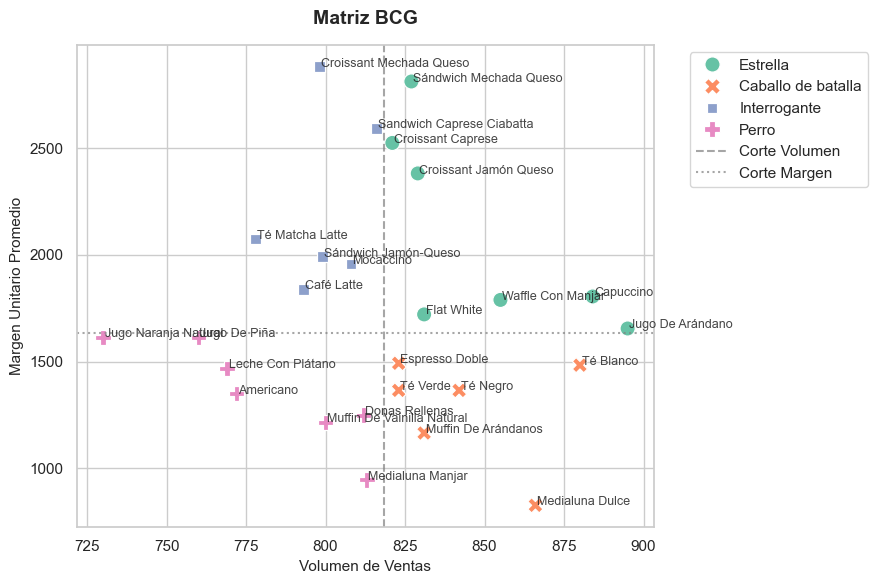

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=menu,
    x="Volumen_Ventas",
    y="Margen_Unitario_Promedio",
    hue="Menu_Engineering",
    style="Menu_Engineering",
    s=120,
    palette="Set2",
)

for i in range(len(menu)):
    plt.text(
        x=menu["Volumen_Ventas"].iloc[i] + 0.5,
        y=menu["Margen_Unitario_Promedio"].iloc[i],
        s=menu["Producto_Detail"].iloc[i],
        fontsize=9,
        alpha=0.85
    )

plt.axvline(
    x=mediana_volumen, color="gray", linestyle="--", alpha=0.7, label="Corte Volumen"
)
plt.axhline(
    y=mediana_margen, color="gray", linestyle=":", alpha=0.7, label="Corte Margen"
)

plt.title("Matriz BCG", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Volumen de Ventas", fontsize=11)
plt.ylabel("Margen Unitario Promedio", fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(PATH_GRAPHIC / "grafico 6", dpi=300, bbox_inches="tight")
plt.show()

**Hallazgos**

- Los productos con categoria "Bebestibles" y "Cafés" son los más rentables con una tasa promedio de margen de 69% ~ 69%, un 2% ~ 3% más que las otras categorias. Sin embargo, Aportan mucho menos a la caja,

- Los productos más caros son correspondientes a su coste. Esto quiere decir que su precio alto viene con un coste alto. Quitando asi, margen de ganancia del producto. A pesar de esto, dado el volumen de venta, estos hacen entrar el mayor flujo de dinero a la caja.

- La matriz BCG expone que productos generan más margen (Vertical) y tienen mucho volumen de ventas (Horizontal). Estos productos se entienden en una venta individual, no en una conjunto de productos comprados.
    - Los productos "Estrella" mantienen margen de ganancia mayor a la mediana y venden más que la mediana. Se recomienda no hacer cambios drasticos.

    - Los productos "Caballo de batalla" tienen menor margen de ganancia pero en cambio tienen alto volumén de ventas. Para estos se recomienda optimizar costes y re-negociar insumos para bajar coste. Si la bajada de coste resulta imposible, se puede probar la subida de precio considerando el peligro de que baje el volumen de ventas.

    - Los productos "Interrogante" tienen alto margen de ganancia pero sin embargo tienen bajo volumen de ventas. Para estos se recomienda capacitar al personal para que den recomendaciones activamente (upselling). Se puede probar un leve rebaja de precio o servirlos en formato de degustación para incentivar el aumento del volumen de ventas.

    - Los productos "Perro" son aquellos que tienen volumen de ventas y margen de ganancia inferiores a la mediana. En estos casos se recomiendan medidas algo más extremas como: 1) Eliminación directa del producto. 2) Reformulación del producto. 3) Subir el precio. Dado que pocos lo piden, esto lo convertiria almenos en un producto con margen aceptable. Y si deja de venderse del todo, se justifica su eliminación.

- Los productos tienen suficientemente poca dispersión como para preocuparse de productos con ventas o margenes anomalos.

- El análisis de co-ocurrencia por ticket revela que varios productos "Caballo de batalla" o "Perro" juegan un rol clave como productos secundarios de soporte o complementarios para un producto principal. Hay muchas combinaciones frecuentes de un producto "Estrella" con uno "Perro" o "Caballo de batalla".

- Existe la posibilidad de crear Combos Estratégicos combinando productos "Estrella" de distintas categorías que naturalmente ya se venden en alto volumen.

---

**¿Existen patrones temporales y operativos?**

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

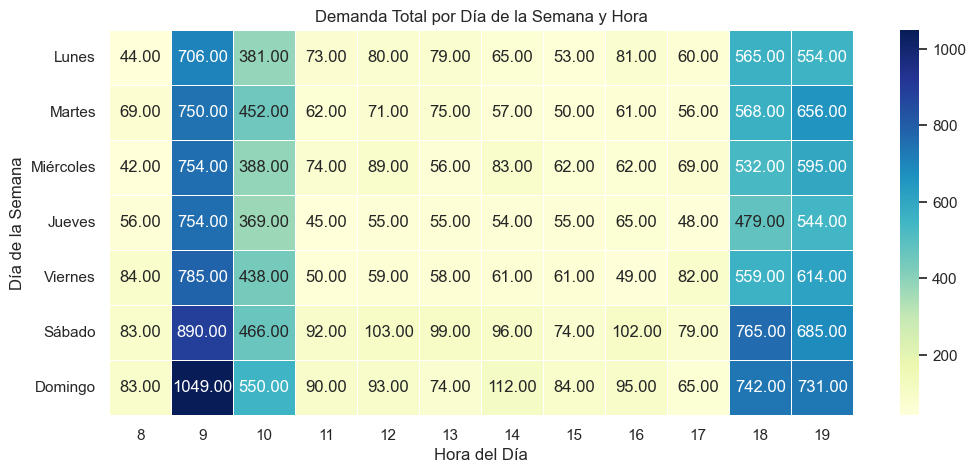

In [87]:
df["Hora"] = df["Fecha_Hora"].dt.hour

dias_es = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}

df["Dia"] = df["Fecha_Hora"].dt.day_name().map(dias_es)

orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
matriz_dia_hora = df.pivot_table(
    index="Dia",
    columns="Hora",
    values="Cantidad",
    aggfunc="sum",
    fill_value=0
).reindex(orden_dias)

plt.figure(figsize=(12, 5))
sns.heatmap(matriz_dia_hora, cmap="YlGnBu", annot=True, fmt=".2f", linewidths=0.5)

plt.title('Demanda Total por Día de la Semana y Hora')
plt.xlabel('Hora del Día')
plt.ylabel('Día de la Semana')
plt.savefig(PATH_GRAPHIC / "grafico 1", dpi=300, bbox_inches="tight")
plt.show()

In [88]:
df["Hora"] = pd.to_datetime(df["Fecha_Hora"]).dt.hour
ventas_hora = df.groupby("Hora")["Cantidad"].sum()

horas_peak = [9, 10, 18, 19]

ventas_peak = ventas_hora.loc[horas_peak].sum()
ventas_totales = ventas_hora.sum()

pct_peak = (ventas_peak / ventas_totales) * 100
print(f"Las horas peak concentran el {pct_peak} de las ventas totales.")

Las horas peak concentran el 81.49141378499176 de las ventas totales.


In [89]:
es_peak = ventas_hora.index.isin(horas_peak)

promedio_peak = ventas_hora[es_peak].mean()
promedio_valle = ventas_hora[~es_peak].mean()

ratio_intensidad = promedio_peak / promedio_valle
print(F"Una hora peak vende {ratio_intensidad} veces más que una hora valle")

Una hora peak vende 8.805795627859684 veces más que una hora valle


In [90]:
df["Dia_Mes"] = pd.to_datetime(df["Fecha_Hora"]).dt.day

ventas_dia_mes = df.groupby("Dia_Mes")["Cantidad"].sum().reset_index()

top_dias = ventas_dia_mes.sort_values(by="Cantidad", ascending=False)
print(top_dias.head(5))

    Dia_Mes  Cantidad
15       16       940
13       14       936
14       15       890
27       28       873
29       30       861


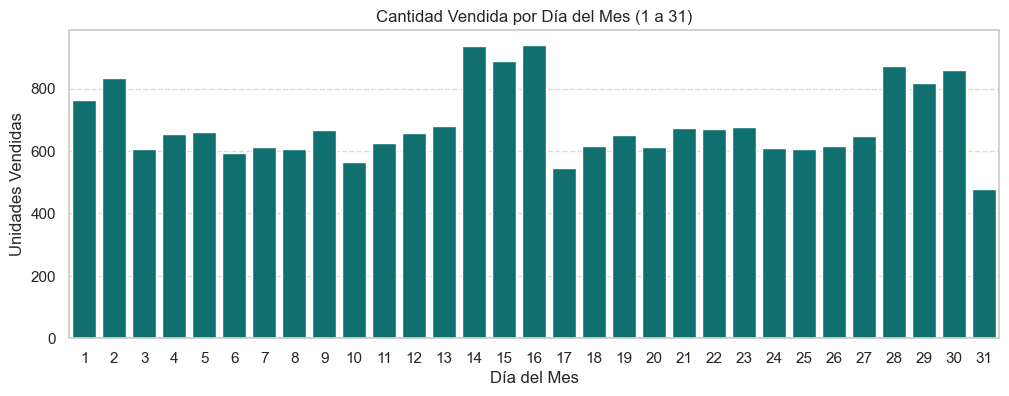

In [91]:
plt.figure(figsize=(12, 4))
sns.barplot(data=ventas_dia_mes, x="Dia_Mes", y="Cantidad", color="teal")

plt.title("Cantidad Vendida por Día del Mes (1 a 31)")
plt.xlabel("Día del Mes")
plt.ylabel("Unidades Vendidas")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig(PATH_GRAPHIC / "grafico 2", dpi=300, bbox_inches="tight")
plt.show()

*El dia 31 contiene una bajada dado que no todos los meses contienen ese dia. Es error de resolución.*

In [92]:
df["Fecha_Hora"] = pd.to_datetime(df["Fecha_Hora"])
df["Dia_Mes"] = df["Fecha_Hora"].dt.day

ventas_dia_mes = df.groupby("Dia_Mes")["Cantidad"].sum()

dias_peak_mes = [14, 15, 16]

es_peak = ventas_dia_mes.index.isin(dias_peak_mes)

promedio_peak = ventas_dia_mes[es_peak].mean()
promedio_valle = ventas_dia_mes[~es_peak].mean()

ratio_intensidad = promedio_peak / promedio_valle

print(F"Un día peak de la quincena vende {ratio_intensidad:.2f} veces más que un día valle del mes.")

Un día peak de la quincena vende 1.40 veces más que un día valle del mes.


In [93]:
df["Fecha_Hora"] = pd.to_datetime(df["Fecha_Hora"])
df["Dia_Mes"] = df["Fecha_Hora"].dt.day

ventas_dia_mes = df.groupby("Dia_Mes")["Cantidad"].sum()

dias_peak_mes = [1, 2, 28, 29, 30]

es_peak = ventas_dia_mes.index.isin(dias_peak_mes)

promedio_peak = ventas_dia_mes[es_peak].mean()
promedio_valle = ventas_dia_mes[~es_peak].mean()

ratio_intensidad = promedio_peak / promedio_valle

print(F"Un día peak de el fin de mes vende {ratio_intensidad:.2f} veces más que un día valle del mes.")

Un día peak de el fin de mes vende 1.26 veces más que un día valle del mes.


**Hallazgos**

- Se pueden observar tendencias horarias en 2 franjas, una entre las 9:00 AM y 10:00 AM, y otra entre las 18:00 PM y 19:00 PM.

- Una hora peak vende 8.7 veces más que una en horario valle.

- Los dias de la semana tienen una ligera concentración en los dias Sábados y Domingos. Tambien considerar que los dias Jueves y Lunes tienden a bajar sus ventas.

- Los días del mes con más ventas son los que rodean a las quincenas y fines de meses. Las quincenas multiplican 1.4 veces las ventas respecto a un dia normal (Valle). Y los fines de mes un 1.26.

---

**¿Qué productos son frecuentemente pedidos juntos? ¿Y cuáles no?**

In [94]:
ventas_por_ticket = df.groupby("ID_Ticket")["Precio_Unitario_Neto"].sum()
ticket_promedio = ventas_por_ticket.mean()

print(F"El ticket promedio es de ${ticket_promedio.astype(int)}.")

El ticket promedio es de $7673.


In [95]:
import pandas as pd

# 1. Definir y asignar los Supergrupos
mapa_supergrupos = {
    'Bebestibles': 'Grupo_Bebidas',
    'Cafés': 'Grupo_Bebidas',
    'Sandwicheria': 'Grupo_Comida',
    'Repostería': 'Grupo_Comida'
}
df['Supergrupo'] = df['Producto_Categoria'].map(mapa_supergrupos)

# 2. Generar pares por ticket
pares = pd.merge(
    df[['ID_Ticket', 'Producto_Detail', 'Supergrupo']], 
    df[['ID_Ticket', 'Producto_Detail', 'Supergrupo']], 
    on='ID_Ticket'
)

# 3. Filtrar para cruzar supergrupos y evitar duplicados/autocoincidencias
filtro_mas_pedidos = (
    (pares["Producto_Detail_x"] < pares["Producto_Detail_y"]) &
    (pares["Supergrupo_x"] != pares["Supergrupo_y"])
)

pares_filtrados = pares[filtro_mas_pedidos]

# 4. Agrupar y ordenar DESCENDENTE (para ver los más vendidos juntos)
frecuencia_pares = (
    pares_filtrados
    .groupby([
        "Producto_Detail_x", "Supergrupo_x", 
        "Producto_Detail_y", "Supergrupo_y"
    ])
    .size()
    .reset_index(name="Veces_Juntos")
    .sort_values(by="Veces_Juntos", ascending=False)
)

print(frecuencia_pares.head(5))

    Producto_Detail_x   Supergrupo_x           Producto_Detail_y  \
87     Espresso Doble  Grupo_Bebidas           Waffle Con Manjar   
91         Flat White  Grupo_Bebidas  Muffin De Vainilla Natural   
1           Americano  Grupo_Bebidas       Croissant Jamón Queso   
100  Jugo De Arándano  Grupo_Bebidas   Sandwich Caprese Ciabatta   
12         Café Latte  Grupo_Bebidas           Croissant Caprese   

     Supergrupo_y  Veces_Juntos  
87   Grupo_Comida            53  
91   Grupo_Comida            53  
1    Grupo_Comida            52  
100  Grupo_Comida            52  
12   Grupo_Comida            52  


In [96]:
import pandas as pd

# 1. Definir y asignar los Supergrupos
mapa_supergrupos = {
    'Bebestibles': 'Grupo_Bebidas',
    'Cafés': 'Grupo_Bebidas',
    'Sandwicheria': 'Grupo_Comida',
    'Repostería': 'Grupo_Comida'
}
df['Supergrupo'] = df['Producto_Categoria'].map(mapa_supergrupos)

# 2. Generar pares por ticket
pares = pd.merge(
    df[['ID_Ticket', 'Producto_Detail', 'Supergrupo']], 
    df[['ID_Ticket', 'Producto_Detail', 'Supergrupo']], 
    on='ID_Ticket'
)

# 3. Filtrar para cruzar supergrupos y evitar duplicados/autocoincidencias
filtro_mas_pedidos = (
    (pares["Producto_Detail_x"] < pares["Producto_Detail_y"]) &
    (pares["Supergrupo_x"] != pares["Supergrupo_y"])
)

pares_filtrados = pares[filtro_mas_pedidos]

# 4. Agrupar y ordenar DESCENDENTE (para ver los más vendidos juntos)
frecuencia_pares = (
    pares_filtrados
    .groupby([
        "Producto_Detail_x", "Supergrupo_x", 
        "Producto_Detail_y", "Supergrupo_y"
    ])
    .size()
    .reset_index(name="Veces_Juntos")
    .sort_values(by="Veces_Juntos", ascending=False)
)

print(frecuencia_pares.tail(5))

        Producto_Detail_x   Supergrupo_x        Producto_Detail_y  \
75         Donas Rellenas   Grupo_Comida                Mocaccino   
73         Donas Rellenas   Grupo_Comida     Jugo Naranja Natural   
42      Croissant Caprese   Grupo_Comida                Mocaccino   
55  Croissant Jamón Queso   Grupo_Comida          Té Matcha Latte   
14             Café Latte  Grupo_Bebidas  Croissant Mechada Queso   

     Supergrupo_y  Veces_Juntos  
75  Grupo_Bebidas            28  
73  Grupo_Bebidas            27  
42  Grupo_Bebidas            26  
55  Grupo_Bebidas            26  
14   Grupo_Comida            21  


In [97]:
mapa_supergrupos = {
    'Bebestibles': 'Grupo_Bebidas',
    'Cafés': 'Grupo_Bebidas',
    'Sandwicheria': 'Grupo_Comida',
    'Repostería': 'Grupo_Comida'
}
df['Supergrupo'] = df['Producto_Categoria'].map(mapa_supergrupos)

precios_prod = df.groupby("Producto_Detail")["Precio_Unitario_Neto"].mean()
precio_promedio = precios_prod.mean()
productos_alto_valor = precios_prod[precios_prod > precio_promedio].index

pares = pd.merge(
    df[["ID_Ticket", "Producto_Detail", "Supergrupo", "Precio_Unitario_Neto"]],
    df[["ID_Ticket", "Producto_Detail", "Supergrupo", "Precio_Unitario_Neto"]],
    on="ID_Ticket"
)

filtro_alto_valor_menos_pedidos = (
    (pares["Producto_Detail_x"] < pares["Producto_Detail_y"]) &
    (pares["Supergrupo_x"] != pares["Supergrupo_y"]) &
    (pares["Producto_Detail_x"].isin(productos_alto_valor)) & 
    (pares["Producto_Detail_y"].isin(productos_alto_valor))
)

pares_filtrados = pares[filtro_alto_valor_menos_pedidos]

frecuencia_pares = (
    pares_filtrados
    .groupby([
        "Producto_Detail_x", "Supergrupo_x",
        "Producto_Detail_y", "Supergrupo_y"
    ])
    .size()
    .reset_index(name="Veces_Juntos")
    .sort_values(by="Veces_Juntos", ascending=True)
)

print(frecuencia_pares.head(5))

          Producto_Detail_x   Supergrupo_x        Producto_Detail_y  \
2                Café Latte  Grupo_Bebidas  Croissant Mechada Queso   
10    Croissant Jamón Queso   Grupo_Comida          Té Matcha Latte   
7         Croissant Caprese   Grupo_Comida                Mocaccino   
11  Croissant Mechada Queso   Grupo_Comida                Mocaccino   
4                Café Latte  Grupo_Bebidas     Sándwich Jamón-Queso   

     Supergrupo_y  Veces_Juntos  
2    Grupo_Comida            21  
10  Grupo_Bebidas            26  
7   Grupo_Bebidas            26  
11  Grupo_Bebidas            29  
4    Grupo_Comida            30  


In [98]:
top_10_pares = frecuencia_pares.head(10)

ventas_por_ticket = df.groupby("ID_Ticket")["Precio_Unitario_Neto"].sum()

resultados = []

for _, row in top_10_pares.iterrows():
    prod_a = row["Producto_Detail_x"]
    prod_b = row["Producto_Detail_y"]

    tickets_a = set(df[df["Producto_Detail"] == prod_a]["ID_Ticket"])
    tickets_b = set(df[df["Producto_Detail"] == prod_b]["ID_Ticket"])
    tickets_combo = list(tickets_a.intersection(tickets_b))

    monto_promedio = ventas_por_ticket.loc[tickets_combo].mean()

    resultados.append({
        "Producto_A": prod_a,
        "Producto_B": prod_b,
        "Veces_Juntos": row["Veces_Juntos"],
        "Ticket_Promedio": monto_promedio
    })

df_top_10_ticket_promedio = pd.DataFrame(resultados)

print(df_top_10_ticket_promedio.sort_values(by="Ticket_Promedio", ascending=False))

                  Producto_A                 Producto_B  Veces_Juntos  \
3    Croissant Mechada Queso                  Mocaccino            29   
0                 Café Latte    Croissant Mechada Queso            21   
7  Sandwich Caprese Ciabatta            Té Matcha Latte            34   
6          Croissant Caprese            Té Matcha Latte            32   
2          Croissant Caprese                  Mocaccino            26   
1      Croissant Jamón Queso            Té Matcha Latte            26   
5                  Mocaccino  Sandwich Caprese Ciabatta            32   
9                 Café Latte      Croissant Jamón Queso            34   
4                 Café Latte       Sándwich Jamón-Queso            30   
8            Té Matcha Latte          Waffle Con Manjar            34   

   Ticket_Promedio  
3     10210.137931  
0     10084.950000  
7      9675.058824  
6      9659.225806  
2      9643.807692  
1      9446.800000  
5      9435.312500  
9      8918.272727  
4      

**Hallazgos**

- El ticket promedio de venta es de $7.673 (Neto).

- Los pares más vendidos actualmente son:

| Pares de productos | Veces pedidas |
| :--- | :---: |
| Espresso Doble y  Waffle Con Manjar | (53) |
| Flat White y Muffin De Vainilla Natural | (53) |
| Americano y Croissant Jamón Queso | (53) |
| Jugo De Arándano y Sandwich Caprese Ciabatta | (52) |
| Café Latte y Croissant Caprese | (52) |

- Los pares menos vendidos actualmente son:

| Pares de productos | Veces pedidas |
| :--- | :---: |
| Café Latte y Croissant Mechada Queso | (21) |
| Croissant Jamón Queso y Té Matcha Latte | (26) | 
| Croissant Caprese y Mocaccino | (26) |
| Donas Rellenas y Jugo Naranja Natural | (27) | 
| Donas Rellenas y Mocaccino | (28) |

- Los pares menos vendidos y que son más caros que el promedio son:

| Pares de productos | Veces pedidas | Ticket promedio |
| :--- | :---: | :---: |
| Croissant Mechada Queso y Mocaccino | (29) | ($10.210) |
| Café Latte y Croissant Mechada Queso | (21) | ($10.084) |
| Sandwich Caprese Ciabatta y Té Matcha Latte | (34) | ($9.675) |
| Croissant Caprese y Té Matcha Latte | (32) | ($9.659) |
| Croissant Caprese y Mocaccino | (26) | ($9.643) |
| Croissant Jamón Queso y Té Matcha Latte | (26) | ($9.446) |
| Mocaccino y Sandwich Caprese Ciabatta | (32) | ($9.435) |
| Café Latte y Croissant Jamón Queso | (34) | ($8.918) |
| Café Latte y Sándwich Jamón-Queso | (30) | ($8.308) |
| Té Matcha Latte y Waffle Con Manjar | (34)  | ($8.278) |

---

**¿Cuánto cambia el servicio a traves de los diferentes canales?**

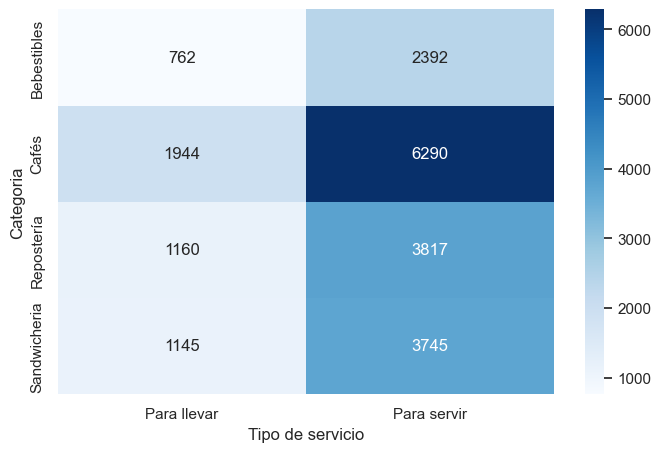

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

matriz = df.pivot_table(
    index="Producto_Categoria",
    columns="Tipo de servicio",
    values="Cantidad",
    aggfunc="sum"
)

plt.figure(figsize=(8, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Tipo de servicio")
plt.ylabel("Categoria")
plt.savefig(PATH_GRAPHIC / "grafico 3", dpi=300, bbox_inches="tight")
plt.show()

In [100]:
print("Valores: ", df["Tipo de servicio"].value_counts())
print("----------------")
print("Porcentaje: ", (df["Tipo de servicio"].value_counts(normalize=True) * 100).round(2))

Valores:  Tipo de servicio
Para servir    10084
Para llevar     3098
Name: count, dtype: int64
----------------
Porcentaje:  Tipo de servicio
Para servir    76.5
Para llevar    23.5
Name: proportion, dtype: float64


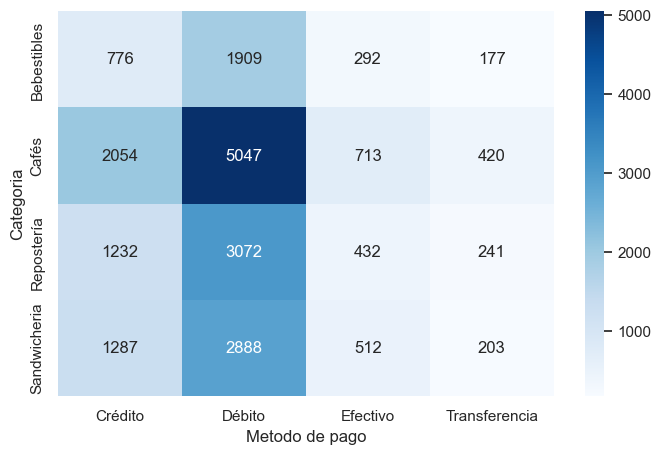

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

matriz = df.pivot_table(
    index="Producto_Categoria",
    columns="Metodo_Pago",
    values="Cantidad",
    aggfunc="sum"
)

plt.figure(figsize=(8, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Metodo de pago")
plt.ylabel("Categoria")
plt.savefig(PATH_GRAPHIC / "grafico 4", dpi=300, bbox_inches="tight")
plt.show()

In [102]:
print("Valores: ", df["Metodo_Pago"].value_counts())
print("----------------")
print("Porcentaje: ", (df["Metodo_Pago"].value_counts(normalize=True) * 100).round(2))

Valores:  Metodo_Pago
Débito           7998
Crédito          3303
Efectivo         1223
Transferencia     658
Name: count, dtype: int64
----------------
Porcentaje:  Metodo_Pago
Débito           60.67
Crédito          25.06
Efectivo          9.28
Transferencia     4.99
Name: proportion, dtype: float64


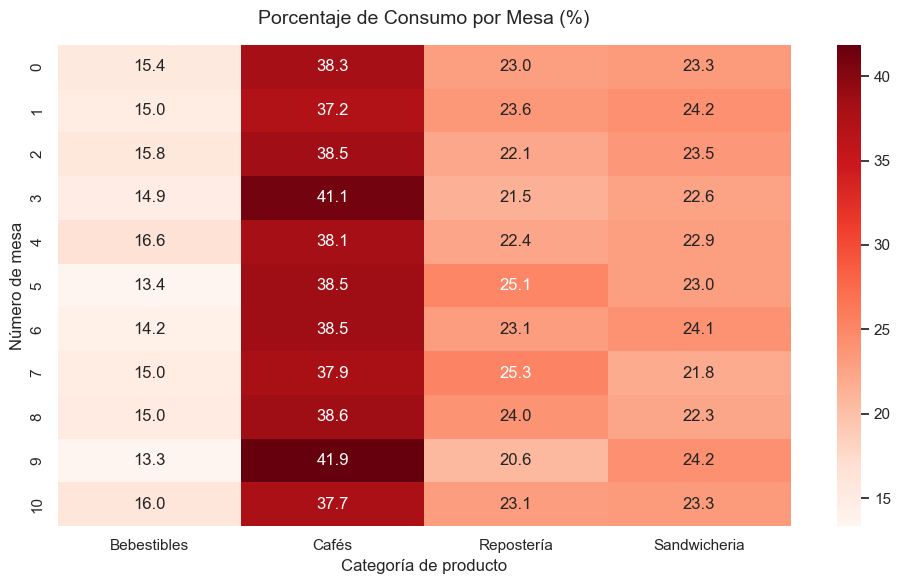

In [103]:
matriz_pct = pd.crosstab(df["Numero de mesa"], df["Producto_Categoria"], normalize="index") * 100

plt.figure(figsize=(10, 6))
sns.heatmap(
    matriz_pct,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar=True
)

plt.title("Porcentaje de Consumo por Mesa (%)", fontsize=14, pad=15)
plt.xlabel("Categoría de producto", fontsize=12)
plt.ylabel("Número de mesa", fontsize=12)

plt.tight_layout()
plt.savefig(PATH_GRAPHIC / "grafico 5", dpi=300, bbox_inches="tight")
plt.show()

In [104]:
print("Valores: ", df["Numero de mesa"].value_counts())
print("----------------")
print("Porcentaje: ", (df["Numero de mesa"].value_counts(normalize=True) * 100).round(2))

Valores:  Numero de mesa
0     3098
6     1588
5     1528
7     1494
8     1482
2      795
1      715
4      711
9      645
3      606
10     520
Name: count, dtype: int64
----------------
Porcentaje:  Numero de mesa
0     23.50
6     12.05
5     11.59
7     11.33
8     11.24
2      6.03
1      5.42
4      5.39
9      4.89
3      4.60
10     3.94
Name: proportion, dtype: float64


**Hallazgos**

- La relación porcentual entre los productos pedidos por Tipo de Servicio:

| Tipo de servicio | Cantidad | Metodo_Pago |
| :---: | :---: | :---: |
| Para servir | 10.084 | 76.5% |
| Para llevar | 3.098 | 23.5% |

- La relación porcentual entre los Metodos de Pago.

| Metodo de pago | Cantidad | Metodo_Pago |
| :---: | :---: | :---: |
| Debito | 7.998 | 60.67% |
| Credito | 3.303 | 25.06% |
| Efectivo | 1223 | 9.28% |
| Transferencia | 658 | 4.99% |

- El top de mesas más ocupadas es:

| Top | Mesa | % |
| :---: | :---: | :---: |
| Top 1 | Mesa 6 | 12.05% |
| Top 2 | Mesa 5 | 11.59% |
| Top 3 | Mesa 7 | 11.33% |
| Top 4 | Mesa 8 | 11.24% |
| Top 5 | Mesa 2 | 6.03% |
| Top 6 | Mesa 1 | 5.42% |
| Top 7 | Mesa 4 | 5.39% |
| Top 8 | Mesa 9 | 4.89% |
| Top 9 | Mesa 3 | 4.60% |
| Top 10 | Mesa 10 | 3.94% |



---

# Tabla Analizada #

In [105]:
print(df.shape)
df

(13182, 20)


,ID_Ticket,RUT_Cliente,Fecha_Hora,Producto_Categoria,Producto_Detail,Cantidad,Precio_Unitario_IVA,Precio_Unitario_Neto,Coste_Producto,Metodo_Pago,Numero de mesa,Tipo de servicio,Margen_Unitario,Ingreso_Total,Margen_Total,Margen_Pct,Hora,Dia,Dia_Mes,Supergrupo
0,TX-20000,987654321,2025-01-01 09:06:00.000000000,Bebestibles,Jugo De Arándano,3,3100,2605,950,Débito,3,Para servir,1655,7815,4965,63.531670,9,Miércoles,1,Grupo_Bebidas
1,TX-20000,987654321,2025-01-01 09:12:07.000000000,Repostería,Muffin De Vainilla Natural,2,2100,1765,550,Débito,3,Para servir,1215,3530,2430,68.838527,9,Miércoles,1,Grupo_Comida
2,TX-20001,CONSUMIDOR FINAL,2025-01-01 09:20:48.000000000,Cafés,Espresso Doble,2,2490,2092,600,Crédito,6,Para servir,1492,4184,2984,71.319312,9,Miércoles,1,Grupo_Bebidas
3,TX-20001,CONSUMIDOR FINAL,2025-01-01 09:22:47.000000000,Bebestibles,Jugo Naranja Natural,1,2990,2513,900,Crédito,6,Para servir,1613,2513,1613,64.186232,9,Miércoles,1,Grupo_Bebidas
4,TX-20001,CONSUMIDOR FINAL,2025-01-01 09:27:58.000000000,Sandwicheria,Croissant Caprese,1,4790,4025,1500,Crédito,6,Para servir,2525,4025,2525,62.732919,9,Miércoles,1,Grupo_Comida
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13177,TX-24497,CONSUMIDOR FINAL,2025-12-31 19:35:19.680000095,Bebestibles,Jugo De Piña,1,2990,2513,900,Débito,7,Para servir,1613,2513,1613,64.186232,19,Miércoles,31,Grupo_Bebidas
13178,TX-24498,CONSUMIDOR FINAL,2025-12-31 19:36:00.000000000,Repostería,Medialuna Dulce,1,1400,1176,350,Débito,2,Para servir,826,1176,826,70.238095,19,Miércoles,31,Grupo_Comida
13179,TX-24498,CONSUMIDOR FINAL,2025-12-31 19:39:13.000000000,Cafés,Flat White,1,3000,2521,800,Débito,2,Para servir,1721,2521,1721,68.266561,19,Miércoles,31,Grupo_Bebidas
13180,TX-24499,CONSUMIDOR FINAL,2025-12-31 19:40:25.000000000,Cafés,Americano,3,2200,1849,500,Débito,6,Para servir,1349,5547,4047,72.958356,19,Miércoles,31,Grupo_Bebidas


In [106]:
df.dtypes

ID_Ticket                       object
RUT_Cliente                     object
Fecha_Hora              datetime64[ns]
Producto_Categoria              object
Producto_Detail                 object
Cantidad                         int64
Precio_Unitario_IVA              int64
Precio_Unitario_Neto             int64
Coste_Producto                   int64
Metodo_Pago                     object
Numero de mesa                   int64
Tipo de servicio                object
Margen_Unitario                  int64
Ingreso_Total                    int64
Margen_Total                     int64
Margen_Pct                     float64
Hora                             int32
Dia                             object
Dia_Mes                          int32
Supergrupo                      object
dtype: object

---

# Export #

In [107]:
df.to_csv(PATH_SALIDA, index=False)